### House prices prediction

In this case study, we will use dataset from UCI repository: https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set
to predict the house prices based on some available features.

In our analysis we will train: **Random Forest Regressor** ,**XGBoost Classifier** and **SVR**, than we will compare which model gives better results.

In [55]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRFRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error

In [9]:
# import dataset
url = "https://raw.githubusercontent.com/Minuri427/DataSet_ML/refs/heads/main/Real%20estate%20valuation%20data%20set.csv"
data = pd.read_csv(url)

In [10]:
data.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


### Exploratory data analysis

In [11]:
data.shape

(414, 7)

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 7 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   X1 transaction date                     414 non-null    float64
 1   X2 house age                            414 non-null    float64
 2   X3 distance to the nearest MRT station  414 non-null    float64
 3   X4 number of convenience stores         414 non-null    int64  
 4   X5 latitude                             414 non-null    float64
 5   X6 longitude                            414 non-null    float64
 6   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 22.8 KB


In [13]:
# Rename columns
cols = ['Transaction date' ,'House age', 'Distance to the nearest MRT station',
        'Number of convenience stores','Latitude', 'Longitude',
        'House price of unit area']

In [14]:
data.columns = cols

In [15]:
data.head()

,Transaction date,House age,Distance to the nearest MRT station,Number of convenience stores,Latitude,Longitude,House price of unit area
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [16]:
# check if there are any missing values
data.isnull().sum()/len(data)

Transaction date                       0.0
House age                              0.0
Distance to the nearest MRT station    0.0
Number of convenience stores           0.0
Latitude                               0.0
Longitude                              0.0
House price of unit area               0.0
dtype: float64

In [17]:
# We can drop transaction date, since this feature is redundant
data.drop(columns=['Transaction date'], axis=1, inplace=True)

In [ ]:
# Descriptive statistics
data.describe()

,House age,Distance to the nearest MRT station,Number of convenience stores,Latitude,Longitude,House price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


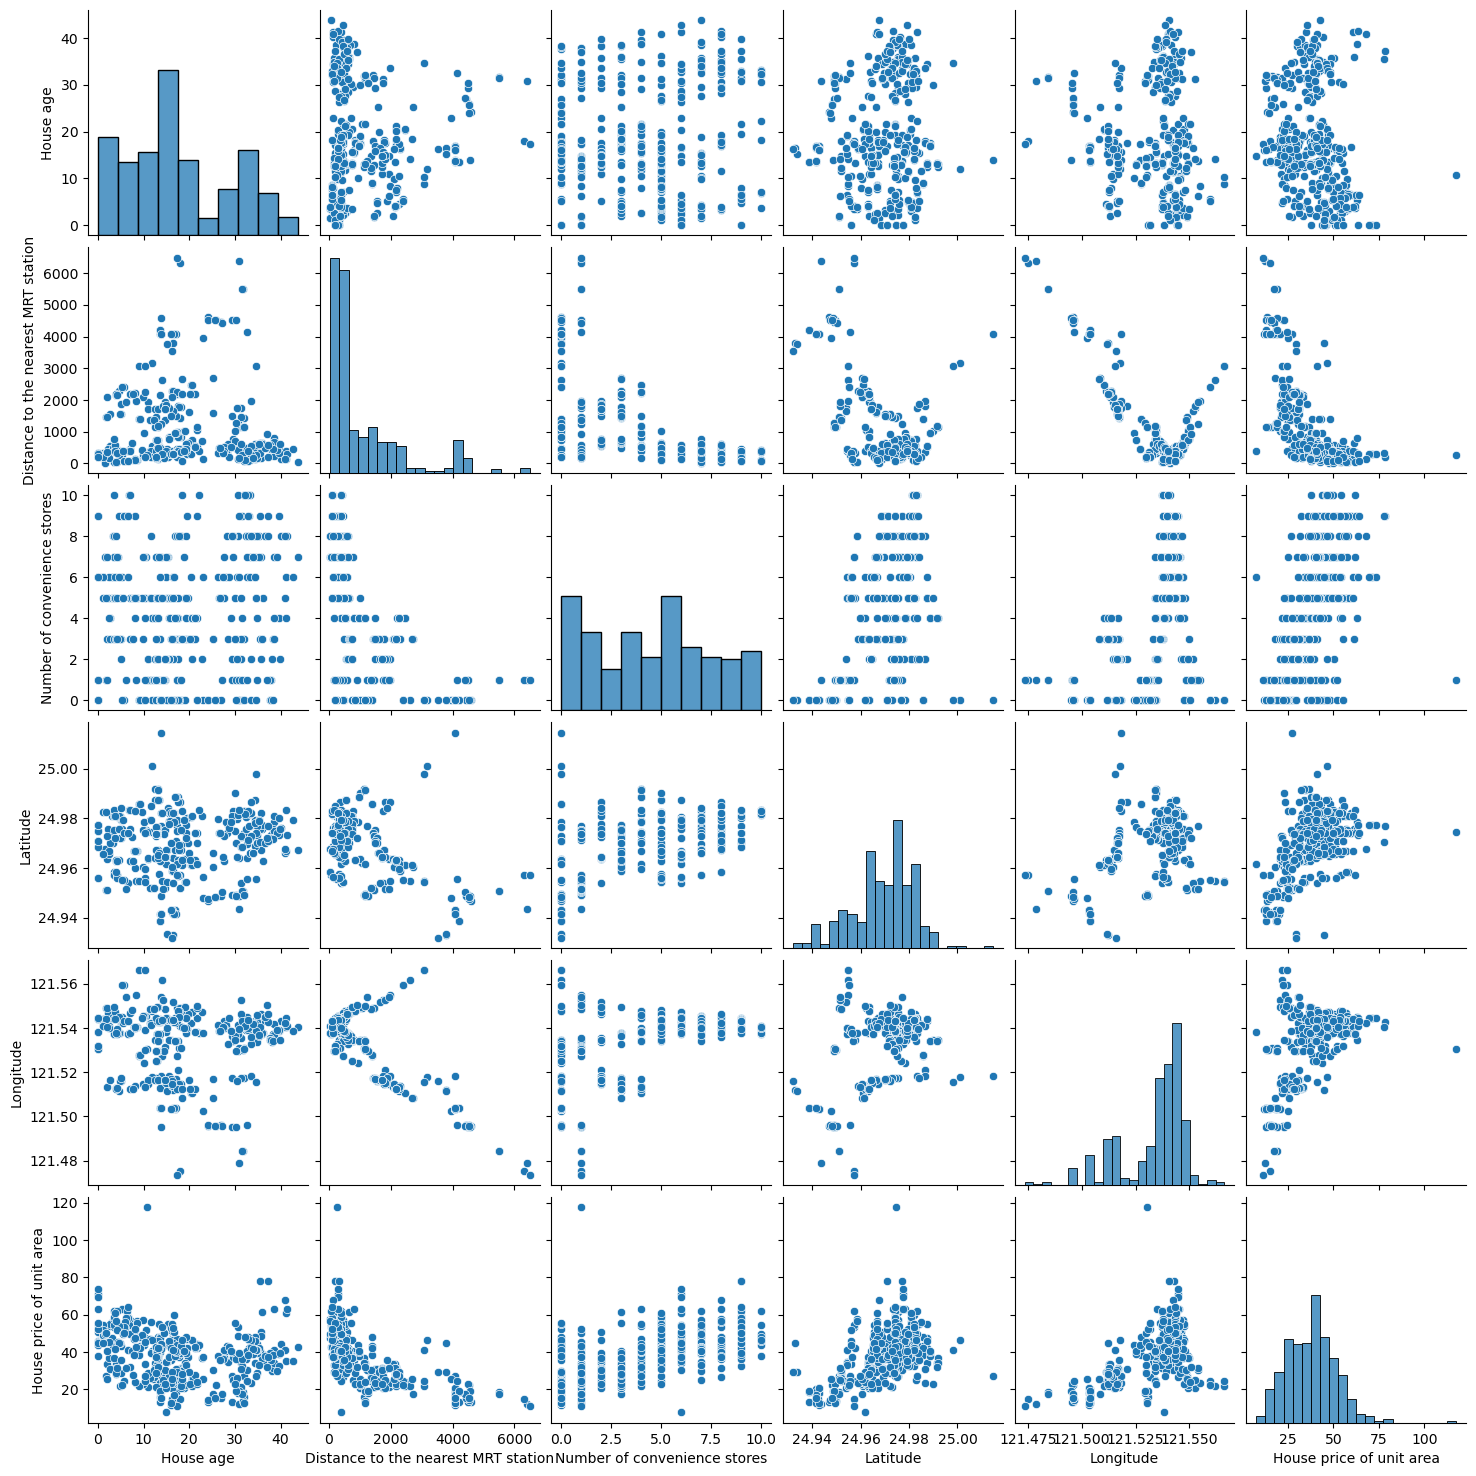

In [19]:
# Check features distribution and correlation
sns.pairplot(data)

From above plot, we conclude that there is no strong positive/negative correlation between the features. The distribution of the predictors is mostly skewed normal, there are several outliers in this dataset.

<AxesSubplot:>

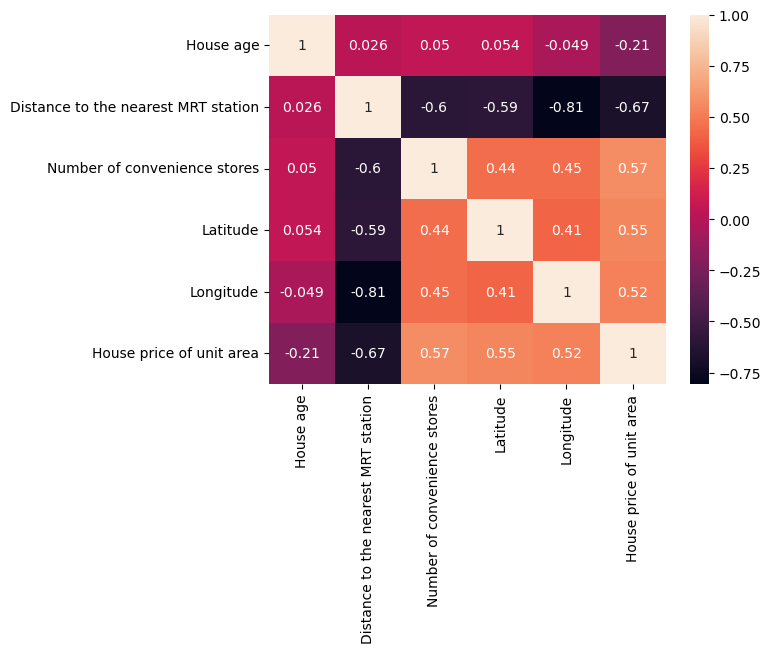

In [20]:
# Check features correlation
sns.heatmap(data.corr(), annot=True)

In [21]:
# Drop 'Distance to the nearest MRT station' variable
data.drop(columns=['Distance to the nearest MRT station'], axis=1, inplace=True)

<AxesSubplot:>

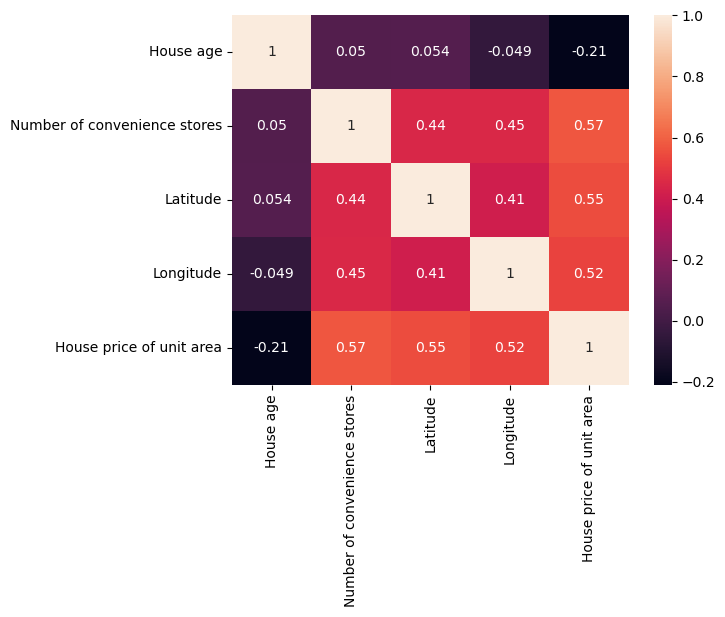

In [22]:
# Check features correlation
sns.heatmap(data.corr(), annot=True)

In [24]:
data.columns

Index(['House age', 'Number of convenience stores', 'Latitude', 'Longitude',
       'House price of unit area'],
      dtype='object')

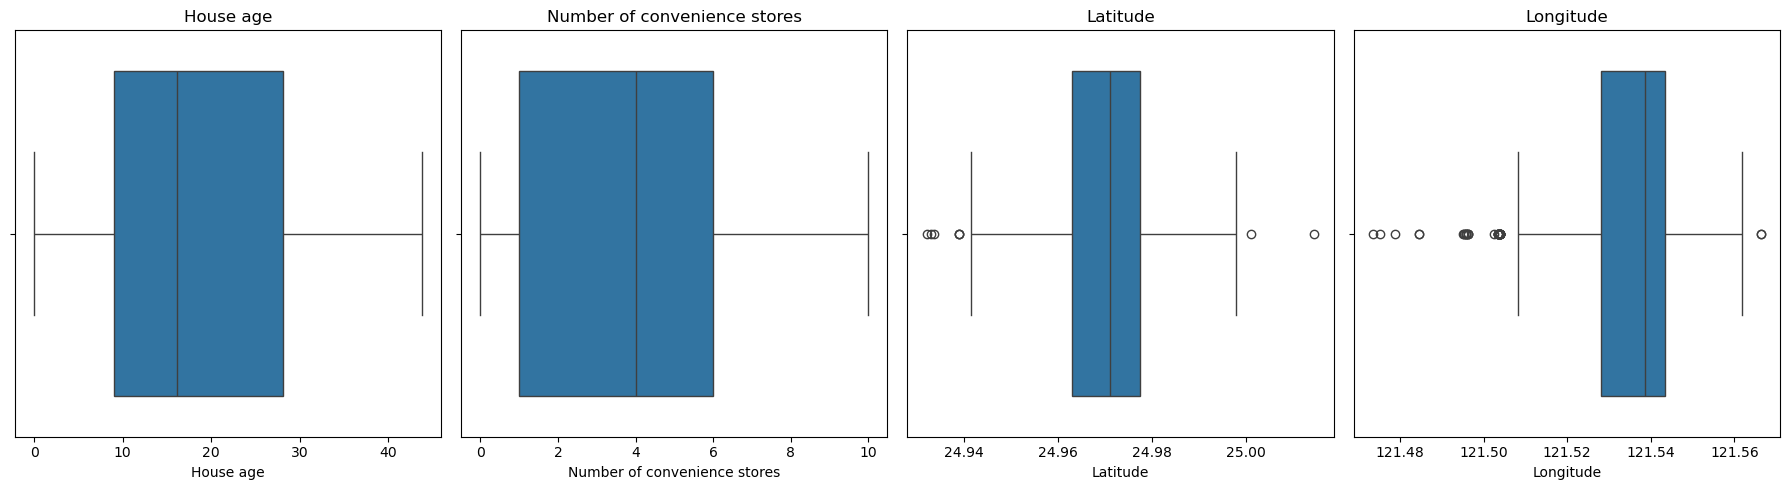

In [25]:
# Detect outliers
cols = ['House age', 'Number of convenience stores', 'Latitude', 'Longitude']

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(18,5))

for i, col in enumerate(cols[:4]):
    sns.boxplot(data=data[col], orient='h', ax=axes[i])
    axes[i].set_title(f'{col}')
plt.tight_layout()
plt.show()

Outliers in Latitude and Longitude in boxplots can be spotted.

In [ ]:
# Remove outliers in Latitude and Longitude variables
df = data[(data['Latitude'] > 24.93) & (data['Latitude'] < 25.01) & (data['Longitude'] > 121.47) & (data['Longitude'] < 121.57)]

In [28]:
df

,House age,Number of convenience stores,Latitude,Longitude,House price of unit area
0,32.0,10,24.98298,121.54024,37.9
1,19.5,9,24.98034,121.53951,42.2
2,13.3,5,24.98746,121.54391,47.3
3,13.3,5,24.98746,121.54391,54.8
4,5.0,5,24.97937,121.54245,43.1
...,...,...,...,...,...
409,13.7,0,24.94155,121.50381,15.4
410,5.6,9,24.97433,121.54310,50.0
411,18.8,7,24.97923,121.53986,40.6
412,8.1,5,24.96674,121.54067,52.5


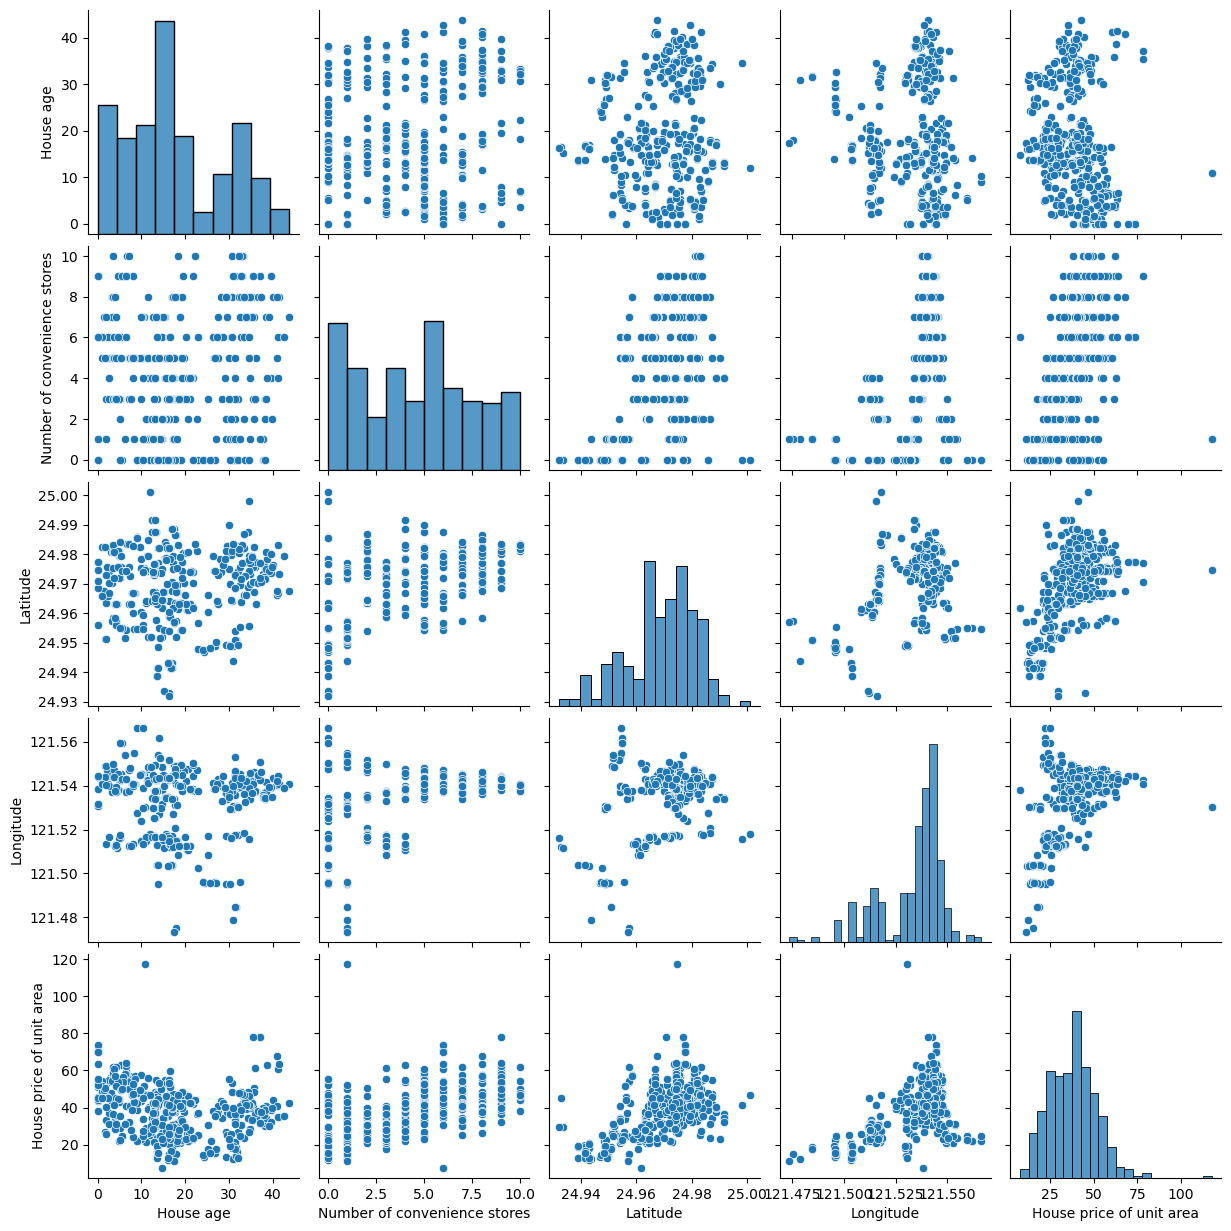

In [ ]:
# Check features distribution and correlation after outliers removal
sns.pairplot(df)

Distribution of features are normal skewed, so we can standarize data.

In [31]:
# Create feature and target variables
X = data.iloc[:,:-1]
y = data.iloc[:,-1]

In [32]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [33]:
# Standarize the data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model traning

Since our dataset is small, we will train **Random Forest regressor** and **XGBoost Regressor**. We will make predictions and evaluate the performance of the models.

#### Random Forest Regressor

In [49]:
# Initialize Random Forest Regressor
rfr = RandomForestRegressor(random_state=42, n_estimators=500)

In [50]:
# Train Random Forest
rfr.fit(X_train, y_train)

RandomForestRegressor(n_estimators=500, random_state=42)

In [51]:
# Make predictions
y_rfr_pred = rfr.predict(X_test)

In [52]:
# Evaluate the performance
r2_score(y_test,y_rfr_pred)

0.7288887045106637

In [54]:
print(mean_squared_error(y_test, y_rfr_pred))

45.336617880492355


#### XGBoost Regressor

In [41]:
# Initialize XGBoost Regressor
xgb = XGBRFRegressor(random_state=42, n_estimator=1000,objective='reg:squarederror')

In [42]:
# Train the model
xgb.fit(X_train_scaled, y_train)

C:\Users\karol\AppData\Roaming\Python\Python39\site-packages\xgboost\core.py:158: UserWarning: [12:53:08] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "n_estimator" } are not used.

  warnings.warn(smsg, UserWarning)


XGBRFRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bytree=None, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimator=1000, n_estimators=None,
               n_jobs=None, num_parallel_tree=None,
               objective='reg:squarederror', random_state=42, ...)

In [43]:
# Make predictions
y_xgb_pred = xgb.predict(X_test_scaled)

In [44]:
# Evaluate the performance
r2_score(y_test, y_xgb_pred)

0.7515995185103517

In [53]:
print(mean_squared_error(y_test, y_xgb_pred))

41.53879937130638


#### SVR

In [124]:
svr = SVR(kernel='rbf', epsilon=0.9) # kernel='poly', gamma=0.9

In [125]:
svr.fit(X_train_scaled, y_train)

SVR(epsilon=0.9)

In [126]:
y_svr_pred = svr.predict(X_test_scaled)

In [127]:
print(r2_score(y_test, y_svr_pred))

0.6021900225219944


In [128]:
print(mean_squared_error(y_test, y_svr_pred))

66.52381969336648


### Summary

In our analysis, we used three regression models (Random Forest, XGBoost and SVR) to predict the house prices based on some features. Since the dataset is small, we used ensemble methods (bagging and boosting) which are considered to be more robust than Linear Regression, even with regularization. 

Models give us similar results, XGBoost performs a little better than Random Forest, wheras SVR did not achieve satisfying results.

 Further improvements can be made and the models can be train using different parameter sets (e.g. using CrossValidation or GridSerachCV). 